
after adding noise students:
total students   : 1200
at risk students : 542 (45.2%)
safe students    : 658 (54.8%)

dataset saved : kodo_students_v2.csv
dataset v2 created : 1200 students
at risk students   : 542 (45.2%)
safe students      : 658 (54.8%)
total features     : 9

first 5 rows:
   logins_per_week  avg_time_per_session  quiz_score_avg  modules_completed  \
0                4             75.043897       49.963210                 14   
1               12             30.593828       96.057145                 11   
2                8             25.941733       78.559515                 15   
3                4             65.588681       67.892679                 18   
4                8             20.055434       32.481491                  7   

   days_since_login  revisit_count  assignment_submissions  forum_activity  \
0                18              4                       7               5   
1                 4              6                      10               8  

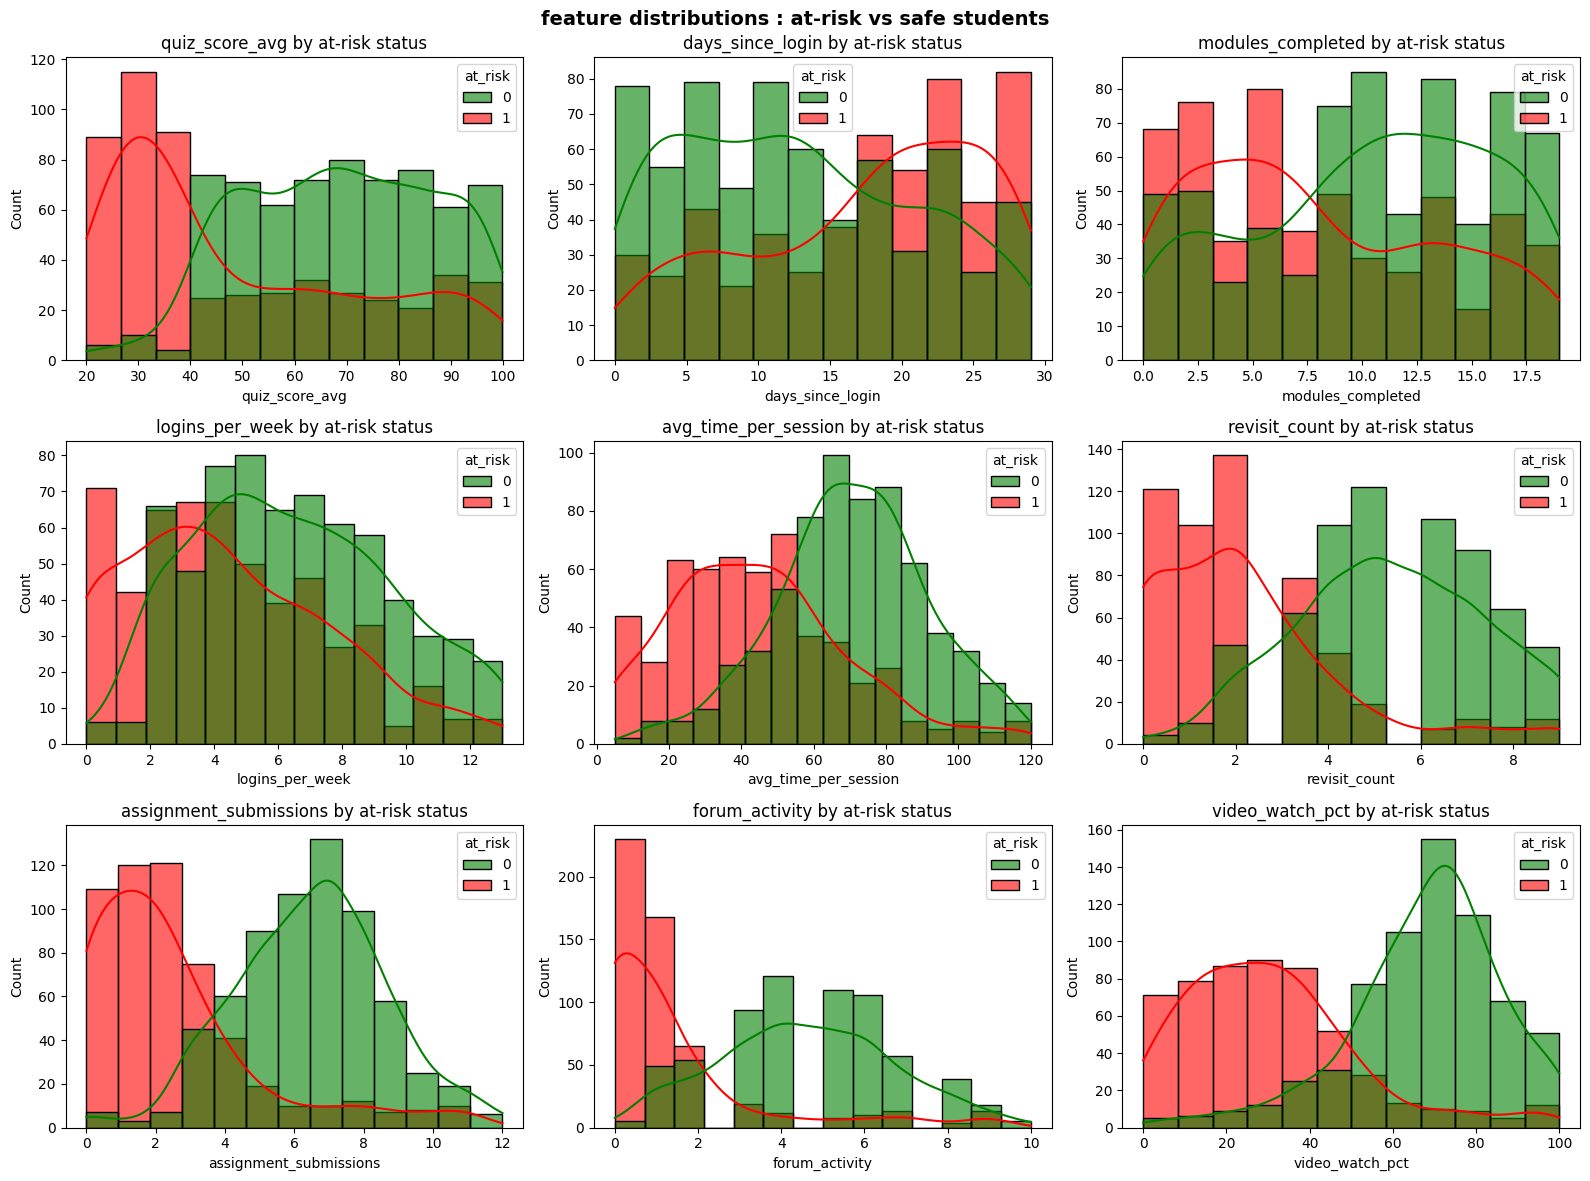

eda plot saved as eda_distributions_v2.png
features shape : (1200, 9)
target shape   : (1200,)

 Train size : 960 students
Test size  : 240 students

 After SMOTE:
At-risk in train : 526
Safe in train    : 526

 Scaling done
Train set (after SMOTE + scaling) : (1052, 9)
Test set  (original + scaled)     : (240, 9)

  Model: Logistic Regression
              precision    recall  f1-score   support

        Safe       0.92      0.97      0.94       132
     At-Risk       0.96      0.90      0.93       108

    accuracy                           0.94       240
   macro avg       0.94      0.93      0.94       240
weighted avg       0.94      0.94      0.94       240

Confusion Matrix:
[[128   4]
 [ 11  97]]
F1 Score : 0.928
ROC-AUC  : 0.956

  Model: Random Forest
              precision    recall  f1-score   support

        Safe       0.93      0.95      0.94       132
     At-Risk       0.94      0.92      0.93       108

    accuracy                           0.94       240
   macro a

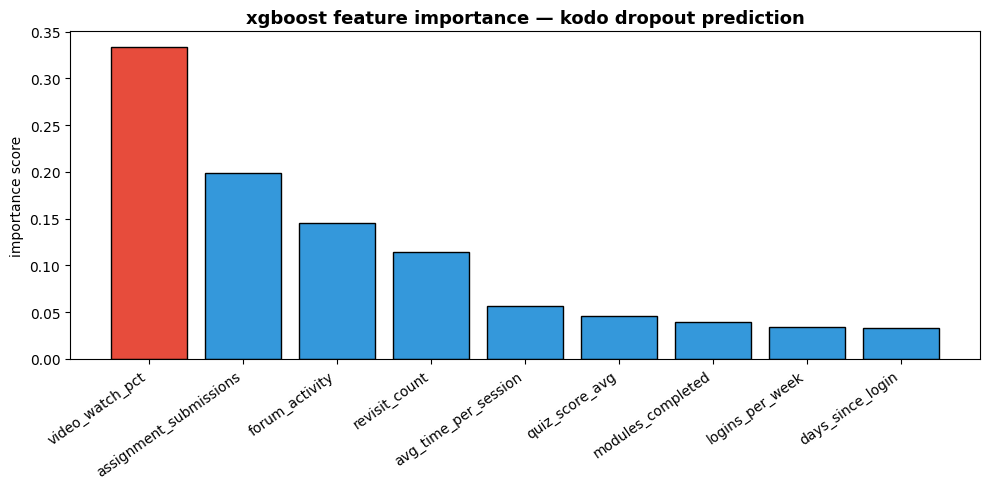

feature importance plot saved

model saved  → kodo_xgboost_model.pkl
scaler saved → kodo_scaler.pkl

ready for flask api!
model loaded successfully
scaler loaded successfully
 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)
ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that

In [16]:
# KODO DROPOUT PREDICTION
#team notes :
#   if you are connecting real KODO student data later just replace cell 1
#   with real data loading and run everything else the same way
#   the 9 features we use are listed in cell 1 — make sure real data has them



# CELL 1 : GENERATE STUDENT DATA (as we dont have rea data )
# Create synthetic student activity data for model training)
# (Replace this section with real KODO data later if available


import numpy as np
import pandas as pd

np.random.seed(42)

# this is imp so our results dont change after  every run

n = 1000
#init we were using 200 but now 1000

# Generating  initial feature values with random data
quiz_score_avg         = np.random.uniform(20, 100, n)
modules_completed      = np.random.randint(0, 20, n)
days_since_login       = np.random.randint(0, 30, n)
logins_per_week        = np.random.randint(0, 14, n)
assignment_submissions = np.random.randint(0, 12, n)
video_watch_pct        = np.random.uniform(0, 100, n)
avg_time_per_session   = np.random.uniform(5, 120, n)
revisit_count          = np.random.randint(0, 10, n)
forum_activity         = np.random.randint(0, 10, n)

# definingg  atrisk label using stricter conditions

at_risk = (
    (quiz_score_avg < 40) |
    ((days_since_login > 15) & (modules_completed < 8)) |
    ((logins_per_week < 2) & (assignment_submissions < 3) & (video_watch_pct < 30))
).astype(int)


#overwrite correlated features based on at risk
# now we regenerate the features WITH noise based on at risk label
# this makes at risk students have worse values on average
# but with overlap so model actually has to learn  not just memorize
# previously we made this too perfect therefore data leakege occured
# now using normal distribution with spread so overlap exists

# also previously loginsweek was dominating at 80% importance (as we made the separation too large)
# at risk mean=2, safe mean=9 ; gap of 7 logins wich isss  too easy to distinguish
# fixing it by bring the means closer together so there is more overlap
# at risk mean=4, safe mean=7 ; gap of only 3 logins therefore harder to distinguish
# also increasing std so distributions overlap more
# therefore model will look for other features too insted of just login

logins_per_week = np.where(
    at_risk == 1,
    np.clip(np.random.normal(4, 3, n), 0, 9).astype(int),   # was mean=2 std=2
    np.clip(np.random.normal(7, 3, n), 2, 13).astype(int)   # was mean=9 std=2
)

# at risk students spend less time per session
# also reducing session time separation for same reason


avg_time_per_session = np.where(
    at_risk == 1,
    np.clip(np.random.normal(40, 20, n), 5, 80),   # was mean=30
    np.clip(np.random.normal(70, 20, n), 20, 120)  # was mean=80
)

# at risk students revisit content less
revisit_count = np.where(
    at_risk == 1,
    np.clip(np.random.normal(2, 1.5, n), 0, 5).astype(int),
    np.clip(np.random.normal(6, 2, n), 2, 9).astype(int)
)

# at risk students submit fewer assignments
assignment_submissions = np.where(
    at_risk == 1,
    np.clip(np.random.normal(2, 1.5, n), 0, 6).astype(int),
    np.clip(np.random.normal(7, 2, n), 3, 12).astype(int)
)

# at risk students barely use forums
forum_activity = np.where(
    at_risk == 1,
    np.clip(np.random.normal(1, 1, n), 0, 4).astype(int),
    np.clip(np.random.normal(5, 2, n), 1, 10).astype(int)
)

# at risk students watch less video content
video_watch_pct = np.where(
    at_risk == 1,
    np.clip(np.random.normal(25, 15, n), 0, 60),
    np.clip(np.random.normal(70, 15, n), 30, 100)
)

#  puting everything into a dataframe
df = pd.DataFrame({
    'logins_per_week'        : logins_per_week,
    'avg_time_per_session'   : avg_time_per_session,
    'quiz_score_avg'         : quiz_score_avg,
    'modules_completed'      : modules_completed,
    'days_since_login'       : days_since_login,
    'revisit_count'          : revisit_count,
    'assignment_submissions' : assignment_submissions,
    'forum_activity'         : forum_activity,
    'video_watch_pct'        : video_watch_pct,
    'at_risk'                : at_risk
})

# also we are saving this  as v2 so we dont overwrite the old dataset

#adding  noise to break the perfect pattern ( as our data is too clean as we genrated the features)
#and due to lables model read that lables perfectly therefore nothing was getting trained
#so we are adding student ho dont follo pattern at all( in wich features and lable dont match)


np.random.seed(99)
n_noise = 200


noise_df = pd.DataFrame({
    # completely random features( no pattern linked to label)
    'logins_per_week'        : np.random.randint(0, 14, n_noise),
    'avg_time_per_session'   : np.random.uniform(5, 120, n_noise),
    'quiz_score_avg'         : np.random.uniform(20, 100, n_noise),
    'modules_completed'      : np.random.randint(0, 20, n_noise),
    'days_since_login'       : np.random.randint(0, 30, n_noise),
    'revisit_count'          : np.random.randint(0, 10, n_noise),
    'assignment_submissions' : np.random.randint(0, 12, n_noise),
    'forum_activity'         : np.random.randint(0, 10, n_noise),
    'video_watch_pct'        : np.random.uniform(0, 100, n_noise),
    # label is also random

    'at_risk'                : np.random.randint(0, 2, n_noise)
})

#combine 1000+200
df = pd.concat([df, noise_df], ignore_index=True)

print(f"\nafter adding noise students:")
print(f"total students   : {len(df)}")
print(f"at risk students : {df['at_risk'].sum()} ({df['at_risk'].mean()*100:.1f}%)")
print(f"safe students    : {(df['at_risk']==0).sum()} ({(df['at_risk']==0).mean()*100:.1f}%)")


# saving after adding noise so csv has the full 1200 students
df.to_csv('kodo_students_v2.csv', index=False)
print(f"\ndataset saved : kodo_students_v2.csv")

print(f"dataset v2 created : {len(df)} students")
print(f"at risk students   : {df['at_risk'].sum()} ({df['at_risk'].mean()*100:.1f}%)")
print(f"safe students      : {(df['at_risk']==0).sum()} ({(df['at_risk']==0).mean()*100:.1f}%)")
print(f"total features     : {df.shape[1]-1}")
print("\nfirst 5 rows:")
print(df.head())



# cell 2 : basic stats to understand our data before doing anything
# describe() gives count, mean, std, min, max for every feature
# this helps us catch weird values before training
# like if min of quiz_score is negative something went wrong in generation

import matplotlib.pyplot as plt
import seaborn as sns

print("=== dataset statistics ===")
print(df.describe().round(2))

# checking class balance
# if at_risk is 90% of data that is a problem for training
# thats why we use SMOTE later to fix this
print(f"\nclass distribution:")
print(df['at_risk'].value_counts())
print(f"at risk % : {df['at_risk'].mean()*100:.1f}%")






# cell 3 : plotting distributions for ALL 9 features


features = [
    'quiz_score_avg', 'days_since_login', 'modules_completed',
    'logins_per_week', 'avg_time_per_session', 'revisit_count',
    'assignment_submissions', 'forum_activity', 'video_watch_pct'
]
# now 9 features

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
# 3 rows 3 columns = 9 plots, one per feature
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue='at_risk',
        kde=True,
        ax=axes[i],
        palette={0:'green', 1:'red'},
        alpha=0.6
    )
    axes[i].set_title(f'{feature} by at-risk status')

plt.suptitle('feature distributions : at-risk vs safe students',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions_v2.png', dpi=150)
plt.show()
print("eda plot saved as eda_distributions_v2.png")




# cell 4 : preprocessing before training
# splitting data, balancing classes with SMOTE, and scaling features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# CELL 4a
# we fixed the data in cell 1 only so no need to fix here this time

# 4b: Split into Features (X) and Target (y)
# X = everything except the label column
# y = the label column only

X = df.drop('at_risk', axis=1)   # axis=1 means drop a column
y = df['at_risk']

print(f"features shape : {X.shape}")  # should be (1000, 9)
print(f"target shape   : {y.shape}")  # should be (1000,)


# 4c: Train / Test Split (80% train, 20% test)
# random_state=42 → same split every run (reproducibility)
# stratify=y (keepss same ratio in both)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n Train size : {X_train.shape[0]} students")
print(f"Test size  : {X_test.shape[0]} students")


# 4d: Applying SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
# fit_resample : learns the minority class pattern & generates new samples

print(f"\n After SMOTE:")
print(f"At-risk in train : {y_train_sm.sum()}")
print(f"Safe in train    : {(y_train_sm==0).sum()}")
# Both should now be equal!


# 4e: Feature Scaling (StandardScaler)
#mean 0 std 1


scaler = StandardScaler()



X_train_scaled = scaler.fit_transform(X_train_sm)   # fit + transform
X_test_scaled  = scaler.transform(X_test)            # transform only

print(f"\n Scaling done")
print(f"Train set (after SMOTE + scaling) : {X_train_scaled.shape}")
print(f"Test set  (original + scaled)     : {X_test_scaled.shape}")



# CELL 5: Train & Compare Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score, roc_auc_score)

# 5a: Define all 3 models
# Logistic Regression → simple baseline (draws a straight line)
# Random Forest       → many decision trees voting together
# XGBoost             → trees built sequentially, each fixing previous errors

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# 5b: Train each model and evaluate
results = {}  # store scores for comparison later

for name, model in models.items():
    print(f"\n{'='*45}")
    print(f"  Model: {name}")
    print(f"{'='*45}")


    model.fit(X_train_scaled, y_train_sm)


    y_pred = model.predict(X_test_scaled)


    f1  = f1_score(y_test, y_pred)


    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

    results[name] = {'F1': round(f1, 3), 'AUC': round(auc, 3)}


    print(classification_report(y_test, y_pred,
                                 target_names=['Safe', 'At-Risk']))

    #actual vs predicted
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cm}")
    print(f"F1 Score : {f1:.3f}")
    print(f"ROC-AUC  : {auc:.3f}")

# 5c: Final comparison table
print(f"\n{'='*45}")
print("  MODEL COMPARISON SUMMARY")
print(f"{'='*45}")
print(f"{'Model':<25} {'F1':>6} {'AUC':>6}")
print("-"*40)
for name, scores in results.items():
    print(f"{name:<25} {scores['F1']:>6} {scores['AUC']:>6}")


    # CELL 6: Hyperparameter Tuning + Cross Validation

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

#6a: Define parameter grid to search (Instead of guessing XGBoost settings, we try all combinations) and let GridSearchCV find the best one automatically


param_grid = {
    'n_estimators'  : [50, 100, 200],        # number of trees
    'max_depth'     : [3, 4, 5],             # how deep each tree grows
    'learning_rate' : [0.01, 0.1, 0.2],      # how fast model learns
    'subsample'     : [0.8, 1.0],            # fraction of data per tree
    'colsample_bytree': [0.8, 1.0]           # fraction of features per tree
}


# 6b: StratifiedKFold
# Instead of one train/test split, we split data into 5 folds
# Model trains on 4 folds, tests on 1 (repeated 5 times)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6c: GridSearchCV (tries all param combinations)
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    cv         = cv,           # 5-fold cross validation
    scoring    = 'f1',         # optimize for F1 score
    n_jobs     = -1,           # use all CPU cores
    verbose    = 1             # show progress
)

print(" Starting GridSearchCV (108 combinations × 5 folds)...")
grid_search.fit(X_train_scaled, y_train_sm)

# 6d: Best parameters found
print(f"\n Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param:<20} : {value}")
print(f"\n Best CV F1 Score : {grid_search.best_score_:.4f}")

# 6e: Evaluate tuned model on test set
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, f1_score, roc_auc_score

print(f"\n{'='*45}")
print("  TUNED XGBoost — Test Set Results")
print(f"{'='*45}")
print(classification_report(y_test, y_pred,
                             target_names=['Safe', 'At-Risk']))
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

# 6f: Cross validation on full data (final check)
# Runing  CV on entire dataset to confirm model is consistent


cv_scores = cross_val_score(
    best_model, X_train_scaled, y_train_sm,
    cv=cv, scoring='f1'
)

print(f"\n 5-Fold CV F1 Scores : {cv_scores.round(4)}")
print(f"   Mean F1            : {cv_scores.mean():.4f}")
print(f"   Std Dev            : {cv_scores.std():.4f}")
# Low std dev = model is consistent across folds = reliable!


# cell 7 - testing the model with manual student profiles


import numpy as np
import pandas as pd

# creating test student profiles manually
# each row is one student with all 9 features


test_students = pd.DataFrame({
    'logins_per_week'        : [1,  10,  3,   8,   0],
    'avg_time_per_session'   : [10, 90,  45,  75,  5],
    'quiz_score_avg'         : [25, 88,  55,  72,  30],
    'modules_completed'      : [2,  17,  9,   14,  1],
    'days_since_login'       : [25, 2,   12,  3,   28],
    'revisit_count'          : [0,  8,   4,   7,   1],
    'assignment_submissions' : [1,  10,  5,   9,   0],
    'forum_activity'         : [0,  8,   3,   6,   0],
    'video_watch_pct'        : [10, 92,  50,  78,  5],
})



expected = ['AT RISK', 'SAFE', 'MIXED', 'SAFE', 'AT RISK']


test_scaled = scaler.transform(test_students)

# get predictions and probabilities
predictions = best_model.predict(test_scaled)
probabilities = best_model.predict_proba(test_scaled)
# predict_proba returns [prob_safe, prob_atrisk] for each student

print("=== model predictions on test students ===\n")
print(f"{'Student':<10} {'Expected':<12} {'Predicted':<12} {'Risk %':<10} {'Match?'}")
print("-" * 55)

for i in range(len(test_students)):
    predicted = 'AT RISK' if predictions[i] == 1 else 'SAFE'
    risk_pct  = probabilities[i][1] * 100  # probability of being at risk

    # check if prediction matches expectation
    # mixed students can go either way so both are fine
    if expected[i] == 'MIXED':
        match = 'ok either way'
    else:
        match = 'yes' if predicted == expected[i] else 'no'

    print(f"Student {i:<3} {expected[i]:<12} {predicted:<12} {risk_pct:<10.1f} {match}")

print("\n=== feature values for each student ===")
print(test_students.to_string())



# cell 8 : feature importance and saving the model
# feature importance tells us which features the model relied on most
# this is useful to know what to focus on

import joblib
import matplotlib.pyplot as plt
import numpy as np

# feature importance from tuned xgboost

feature_names = list(test_students.columns)
importances   = best_model.feature_importances_

# sorting features by importance high to low
indices = np.argsort(importances)[::-1]

print("=== feature importance rankings ===\n")
for rank, idx in enumerate(indices):
    bar = '█' * int(importances[idx] * 60)
    print(f"{rank+1}. {feature_names[idx]:<25} {importances[idx]:.4f}  {bar}")

#  plotting  the feature importance
# highlighting the top feature in red so it stands out
colors = ['#e74c3c' if importances[i] == max(importances)
          else '#3498db' for i in indices]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)),
        importances[indices],
        color=colors, edgecolor='black')
plt.xticks(range(len(importances)),
           [feature_names[i] for i in indices],
           rotation=35, ha='right')
plt.title('xgboost feature importance — kodo dropout prediction',
          fontweight='bold', fontsize=13)
plt.ylabel('importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("feature importance plot saved")

#saving model and scaler


joblib.dump(best_model, 'kodo_xgboost_model.pkl')
joblib.dump(scaler,     'kodo_scaler.pkl')

print("\nmodel saved  → kodo_xgboost_model.pkl")
print("scaler saved → kodo_scaler.pkl")
print("\nready for flask api!")





